In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

* *In this notebook, You can see how a model not only predict a single value, but a sort of a bell curve.*

* *Where it figures out the mergin of error from the real value to the center of bell curve. It then tries to minimize that error.*

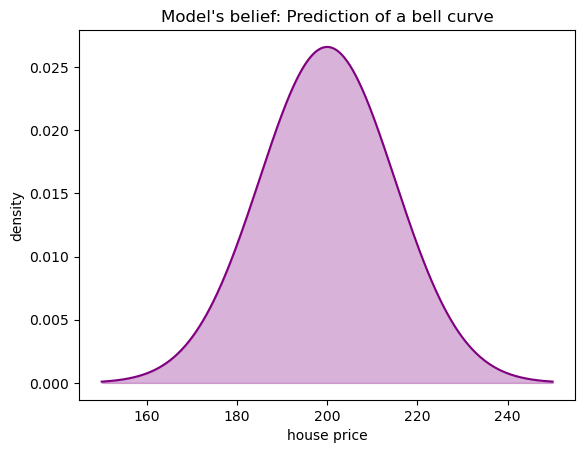

In [6]:
prediction = 200 # the value that model predicts
sigma = 15 # model's uncertaintly
 
x = np.linspace(150, 250, 500)
y = norm.pdf(x, prediction, sigma)

plt.plot(x, y, color='purple')
plt.fill_between(x, y, alpha=0.3, color='purple')
plt.xlabel("house price")
plt.ylabel("density")
plt.title("Model's belief: Prediction of a bell curve")
plt.show()

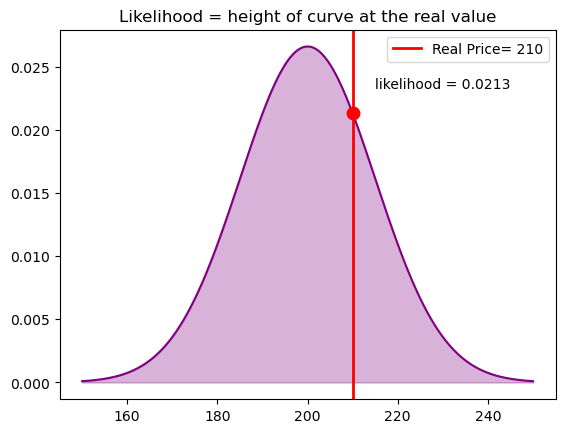

In [31]:
real_price = 210
likelihood = norm.pdf(real_price, prediction, sigma)

plt.plot(x, y, color='purple')
plt.fill_between(x, y, alpha=0.3, color='purple')
plt.axvline(real_price, color='red', linewidth=2, label=f'Real Price= {real_price}')
plt.scatter([real_price], [likelihood], color='red', zorder=5, s=80)
plt.annotate(f'likelihood = {likelihood:.4f}', xy=(real_price, likelihood),
             xytext=(real_price + 5, likelihood + 0.002))

plt.legend()
plt.title("Likelihood = height of curve at the real value")
plt.show()

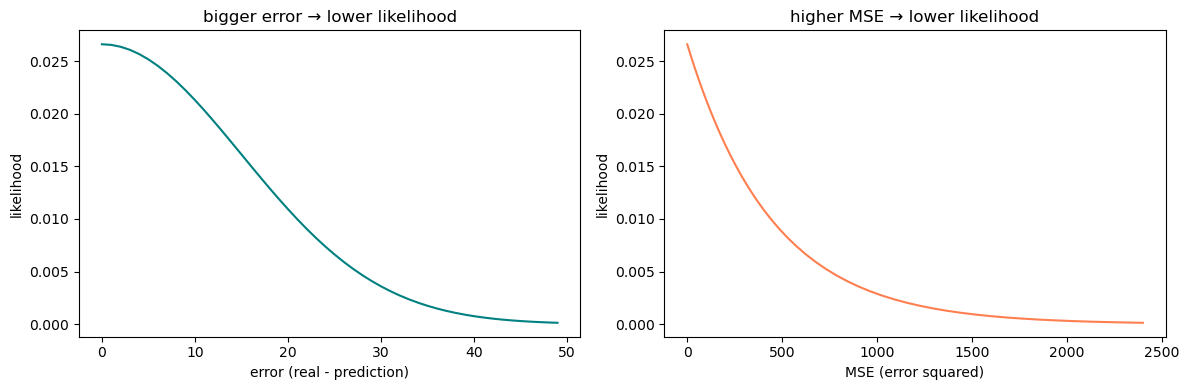

In [ ]:
errors = np.arange(0, 50, 1) # errors form 0 to 49
likelihoods = norm.pdf(prediction + errors, prediction, sigma)
# for each error, we check the likelihood.
# the real price = prediction + error.
# norm.pdf gives the height of the bell curve at the real price.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(errors, likelihoods, color='teal')
ax1.set_xlabel("error (real - prediction)")
ax1.set_ylabel("likelihood")
ax1.set_title("bigger error → lower likelihood")

mse_values = errors**2
ax2.plot(mse_values, likelihoods, color='coral')
ax2.set_xlabel("MSE (error squared)")
ax2.set_ylabel("likelihood")
ax2.set_title("higher MSE → lower likelihood")

plt.tight_layout()
plt.show()

# This shows that when likelihood is highest the error will be the lowest.
# The lower the likelihood the higher the mse/error.
# I just created the 2nd plot to show mse instead or error to visualize that it results will be the same for both the errors and mse.

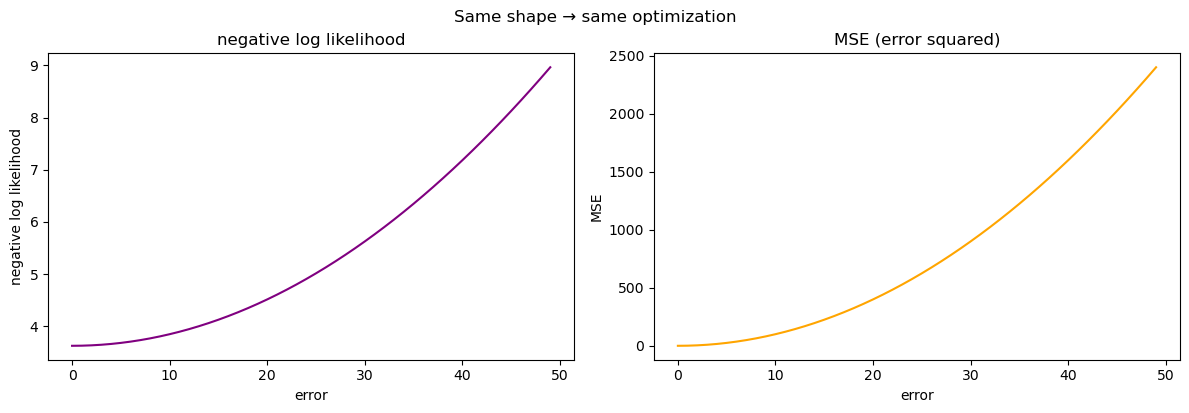

Both curves have the same minimum at error = 0. Minimizing MSE = maximizing likelihood.


In [ ]:
log_likelihoods = np.log(likelihoods) # taking the log for each likelihood.

# In practice, if we multiply all the likelihoods values as they are very samll numbers, it will result in a small unprecise number, but taking the log of likelihoods.
# it will be the same thing but for now it will give us the same correct result if we do addition.
# The maths works out identically, maximizing the log-likelihood will maximize the likelihood.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(errors, -log_likelihoods, color='purple')
ax1.set_xlabel("error")
ax1.set_ylabel("negative log likelihood")
ax1.set_title("negative log likelihood")

ax2.plot(errors, mse_values, color='orange')
ax2.set_xlabel("error")
ax2.set_ylabel("MSE")
ax2.set_title("MSE (error squared)")

plt.tight_layout()
plt.suptitle("Same shape → same optimization", y=1.02)
plt.show()
print("Both curves have the same minimum at error = 0. Minimizing MSE = maximizing likelihood.")
# The visulze shows that minimizing the mse will result in minimizing the likelihood.

## What this notebook shows

1. A model predicts a bell curve centered on its guess.
2. The real value's HEIGHT on that curve = likelihood (how believable the real value was).
3. Smaller error → the real value sits nearer the peak → higher height → higher likelihood.
4. Minimizing MSE and maximizing likelihood are the same instruction said two ways.
5. MSE comes from assuming Gaussian errors. Change the distribution → different loss function.
   - Gaussian  → MSE
   - Laplace   → MAE
   - Categorical → Cross-entropy